In [1]:
# =========================
# 1. IMPORT VÀ TẢI DỮ LIỆU
# =========================

from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import SGD, Adam

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

data_folder = "~/data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

unique_values = tr_targets.unique()

print("tr_images & tr_targets:")
print("X -", tr_images.shape)
print("Y -", tr_targets.shape)
print("Y - Unique Values:", unique_values)
print("TASK:")
print(len(unique_values), "class Classification")
print("UNIQUE CLASSES:")
print(fmnist.classes)

ModuleNotFoundError: No module named 'torchvision'

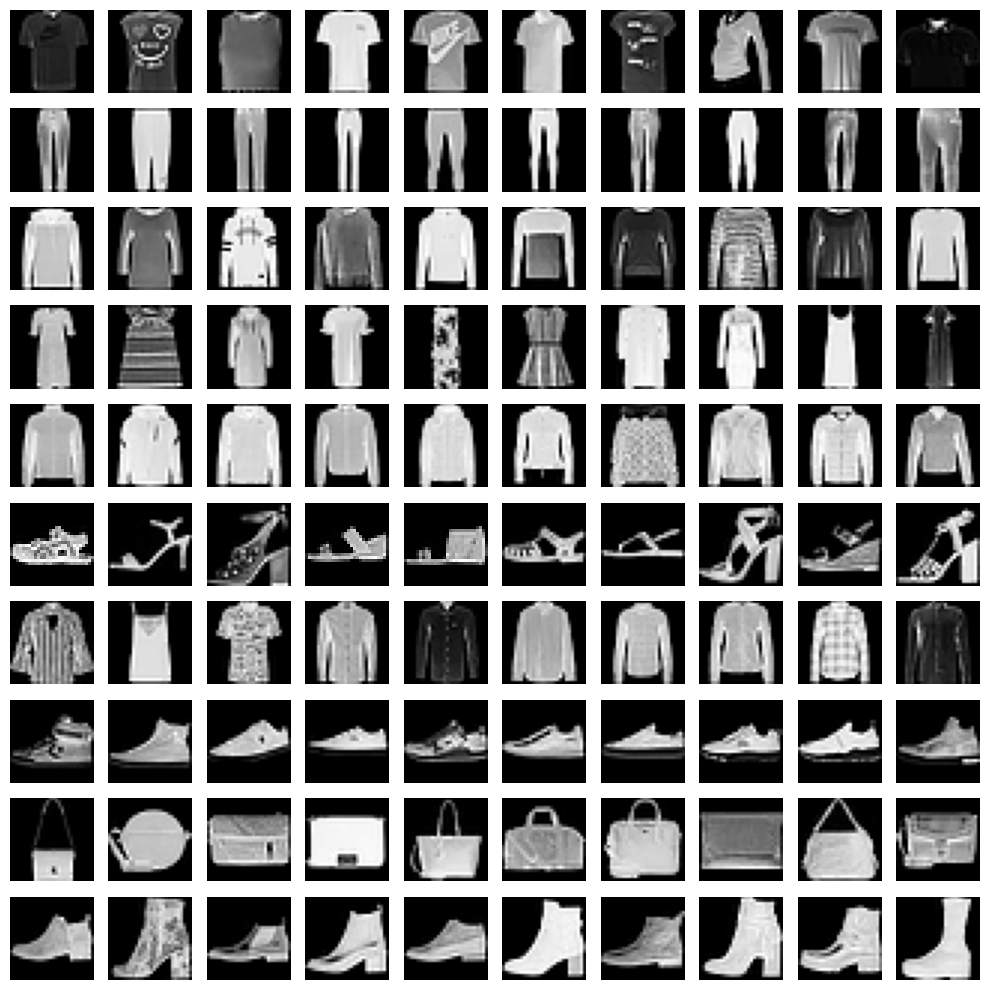

In [ ]:
# =========================
# 2. HIỂN THỊ ẢNH MẪU
# =========================

R, C = len(tr_targets.unique()), 10

fig, ax = plt.subplots(R, C, figsize=(10, 10))

for label_class, plot_row in enumerate(ax):
    label_x_rows = np.where(tr_targets == label_class)[0]

    for plot_cell in plot_row:
        plot_cell.grid(False)
        plot_cell.axis("off")

        ix = np.random.choice(label_x_rows)
        x, y = tr_images[ix], tr_targets[ix]

        plot_cell.imshow(x, cmap="gray")

plt.tight_layout()
plt.show()

Epoch: 1
Loss: 61.01123531405131
Accuracy: 0.13535
Epoch: 2
Loss: 2.2053437916437786
Accuracy: 0.17688333333333334
Epoch: 3
Loss: 2.2616727522532147
Accuracy: 0.15211666666666668
Epoch: 4
Loss: 2.289662817255656
Accuracy: 0.11016666666666666
Epoch: 5
Loss: 2.2595720012664793
Accuracy: 0.13671666666666665


/tmp/ipykernel_7937/505486243.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])


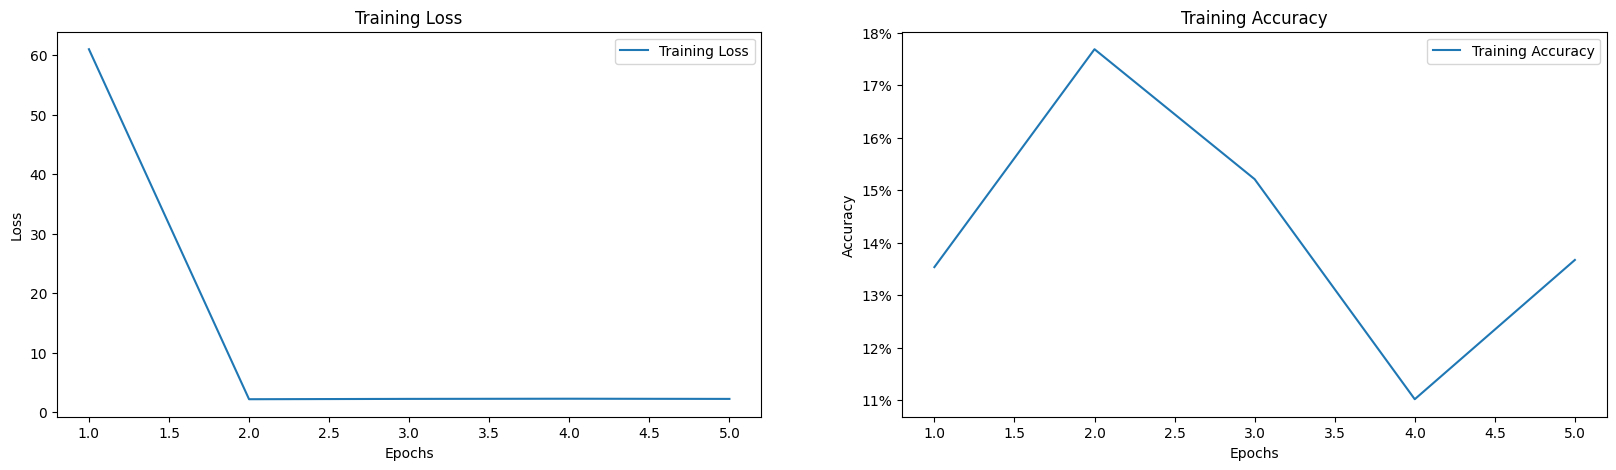

In [ ]:
# ======================================================
# 3. HUẤN LUYỆN MẠNG NƠ-RON - CHƯA CHIA ẢNH CHO 255
# ======================================================

class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl


def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    return batch_loss.item()


@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


trn_dl = get_data()
model, loss_fn, optimizer = get_model()

losses, accuracies = [], []

for epoch in range(5):
    print("Epoch:", epoch + 1)

    epoch_losses, epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)

    epoch_loss = np.array(epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)

    epoch_accuracy = np.mean(epoch_accuracies)

    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

    print("Loss:", epoch_loss)
    print("Accuracy:", epoch_accuracy)


epochs = np.arange(5) + 1

plt.figure(figsize=(20, 5))

plt.subplot(121)
plt.title("Training Loss")
plt.plot(epochs, losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(122)
plt.title("Training Accuracy")
plt.plot(epochs, accuracies, label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()

plt.show()

Epoch: 1
Train Loss: 0.5402263331254323
Train Accuracy: 0.84735
Validation Loss: 0.4797295331954956
Validation Accuracy: 0.8307
Epoch: 2
Train Loss: 0.4389885906656583
Train Accuracy: 0.8628666666666667
Validation Loss: 0.4482230544090271
Validation Accuracy: 0.8447
Epoch: 3
Train Loss: 0.41676596322755016
Train Accuracy: 0.84015
Validation Loss: 0.49466586112976074
Validation Accuracy: 0.825
Epoch: 4
Train Loss: 0.4055082157711188
Train Accuracy: 0.85625
Validation Loss: 0.4846811592578888
Validation Accuracy: 0.8374
Epoch: 5
Train Loss: 0.3944843695779641
Train Accuracy: 0.8685
Validation Loss: 0.44482186436653137
Validation Accuracy: 0.849


/tmp/ipykernel_7937/2416234636.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])


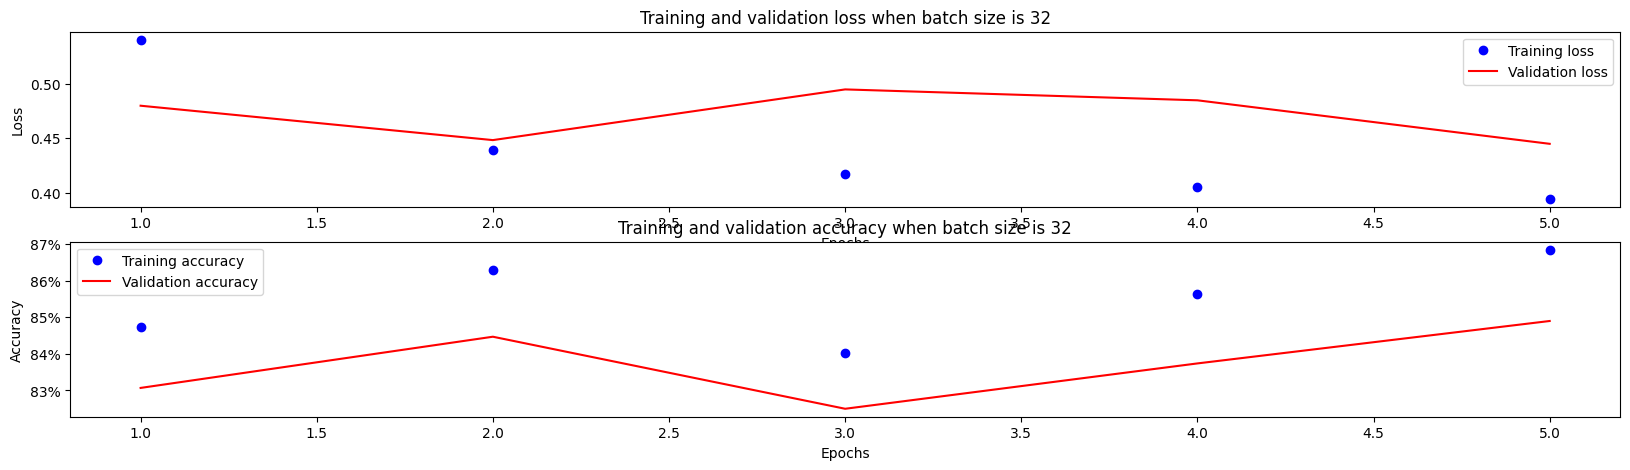

In [ ]:
# ======================================================
# 5. THÊM TẬP VALIDATION, DÙNG ADAM, BATCH SIZE = 32
# ======================================================

val_fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=False
)

val_images = val_fmnist.data
val_targets = val_fmnist.targets


class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


def get_data(batch_size=32):
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=batch_size, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()


@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


@torch.no_grad()
def val_loss(x, y, model):
    model.eval()

    prediction = model(x)
    validation_loss = loss_fn(prediction, y)

    return validation_loss.item()


trn_dl, val_dl = get_data(batch_size=32)
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print("Epoch:", epoch + 1)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

    print("Train Loss:", train_epoch_loss)
    print("Train Accuracy:", train_epoch_accuracy)
    print("Validation Loss:", validation_loss)
    print("Validation Accuracy:", val_epoch_accuracy)


epochs = np.arange(5) + 1

plt.figure(figsize=(20, 5))

plt.subplot(211)
plt.plot(epochs, train_losses, "bo", label="Training loss")
plt.plot(epochs, val_losses, "r", label="Validation loss")
plt.title("Training and validation loss when batch size is 32")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
plt.title("Training and validation accuracy when batch size is 32")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)

plt.show()

Device: cpu
Epoch: 1
Train Loss: 3.72092467546463
Train Accuracy: 0.4453666666666667
Validation Loss: 1.5321037769317627
Validation Accuracy: 0.4416
----------------------------------------
Epoch: 2
Train Loss: 1.1009379625320435
Train Accuracy: 0.7151666666666666
Validation Loss: 0.7921613454818726
Validation Accuracy: 0.7068
----------------------------------------
Epoch: 3
Train Loss: 0.7166805267333984
Train Accuracy: 0.7551666666666667
Validation Loss: 0.6729943156242371
Validation Accuracy: 0.7424
----------------------------------------
Epoch: 4
Train Loss: 0.6087087392807007
Train Accuracy: 0.791
Validation Loss: 0.5874578356742859
Validation Accuracy: 0.776
----------------------------------------
Epoch: 5
Train Loss: 0.5391016105810801
Train Accuracy: 0.8237666666666666
Validation Loss: 0.5288162231445312
Validation Accuracy: 0.813
----------------------------------------


/tmp/ipykernel_7937/2658133195.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])


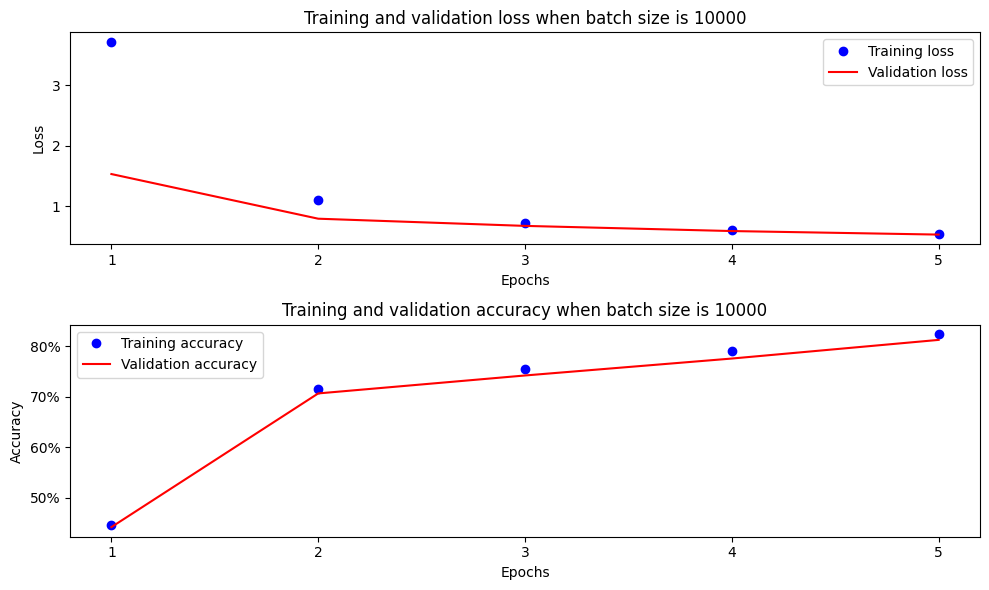

In [ ]:
# ================================
# CÂU 6: THAY ĐỔI BATCH SIZE = 10000
# ================================

from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Thiết bị chạy
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Tải dữ liệu FashionMNIST
data_folder = "~/data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=False
)

val_images = val_fmnist.data
val_targets = val_fmnist.targets


# Tạo Dataset
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


# Hàm lấy dữ liệu với batch size = 10000
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=10000, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


# Xây dựng mô hình
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


# Hàm huấn luyện một batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()


# Hàm tính độ chính xác
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


# Hàm tính loss trên validation
@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()

    prediction = model(x)
    validation_loss = loss_fn(prediction, y)

    return validation_loss.item()


# Gọi DataLoader, model, loss, optimizer
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []


# Huấn luyện 5 epoch
for epoch in range(5):
    print("Epoch:", epoch + 1)

    train_epoch_losses = []
    train_epoch_accuracies = []

    # Train
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    # Tính accuracy trên tập train
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    # Validation
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

    print("Train Loss:", train_epoch_loss)
    print("Train Accuracy:", train_epoch_accuracy)
    print("Validation Loss:", validation_loss)
    print("Validation Accuracy:", val_epoch_accuracy)
    print("-" * 40)


# Vẽ biểu đồ
epochs = np.arange(5) + 1

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, "bo", label="Training loss")
plt.plot(epochs, val_losses, "r", label="Validation loss")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation loss when batch size is 10000")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation accuracy when batch size is 10000")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
# ================================
# SGD OPTIMIZER
# ================================

from torchvision import datasets
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import SGD, Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'

data_folder = '~/data/FMNIST'

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets


class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()


@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


@torch.no_grad()
def val_loss(x, y, model):
    model.eval()

    prediction = model(x)
    validation_loss = loss_fn(prediction, y)

    return validation_loss.item()


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(10):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

0
1
2
3
4
5
6
7
8
9


/tmp/ipykernel_7937/710245594.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])


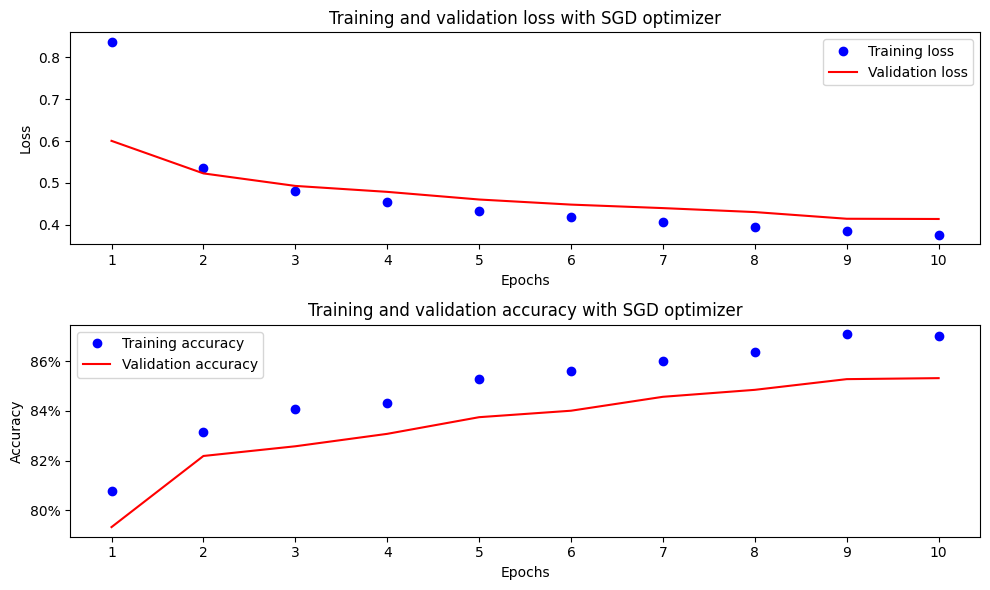

In [ ]:
# ================================
# VẼ BIỂU ĐỒ SGD
# ================================

epochs = np.arange(10) + 1

import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with SGD optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with SGD optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
# ================================
# ADAM OPTIMIZER
# ================================

from torch.optim import SGD, Adam

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(10):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

0
1
2
3
4
5
6
7
8
9


/tmp/ipykernel_7937/3472857822.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])


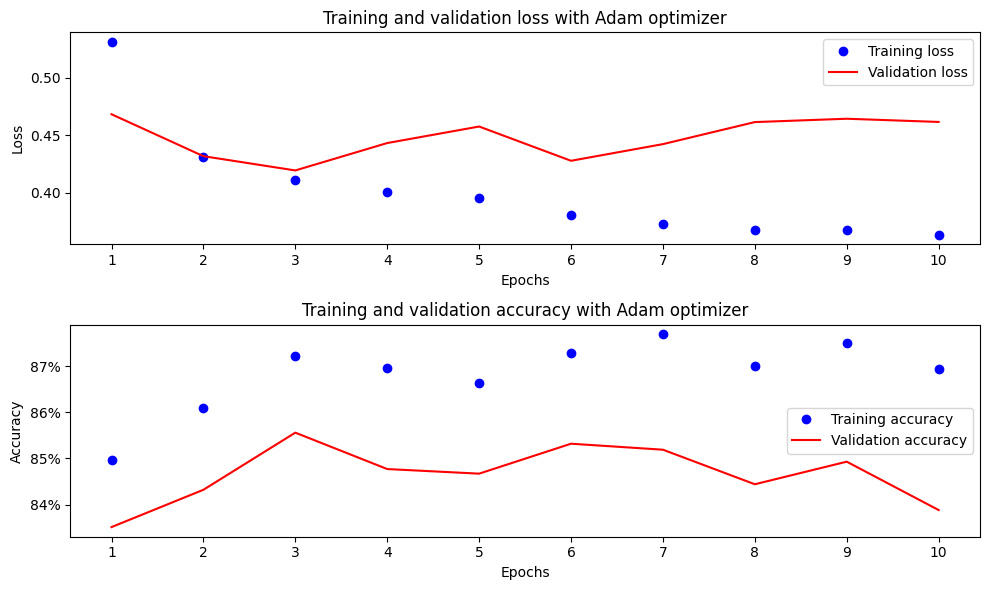

In [ ]:
# ================================
# VẼ BIỂU ĐỒ ADAM
# ================================

epochs = np.arange(10) + 1

import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with Adam optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with Adam optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
# ================================
# HIGH LEARNING RATE - ADAM lr = 0.1
# ================================

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-1)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(10):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

0
1
2
3
4
5
6
7
8
9


/tmp/ipykernel_7937/413035551.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])


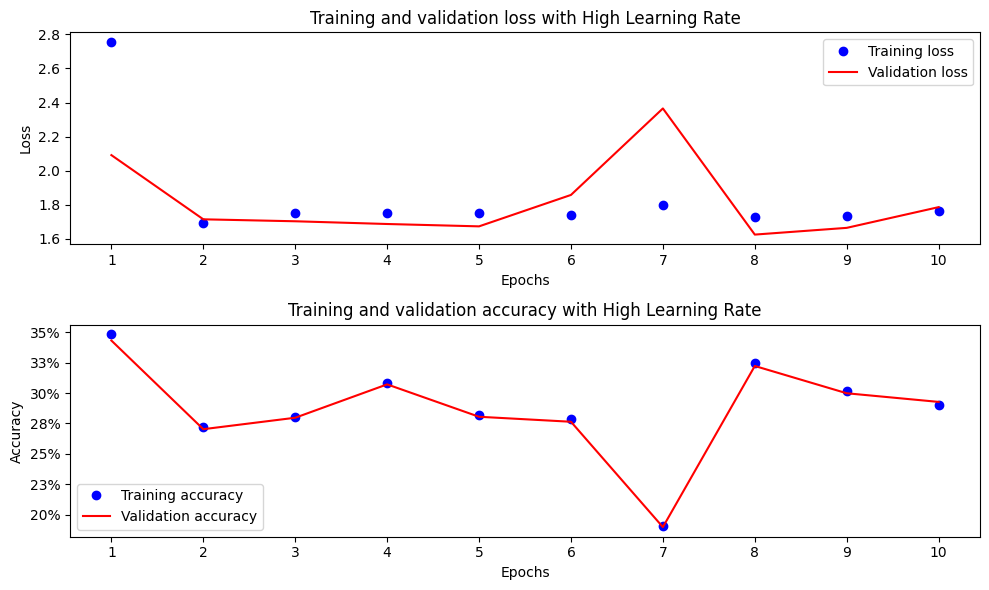

In [ ]:
# ================================
# VẼ BIỂU ĐỒ ADAM lr = 0.1
# ================================

epochs = np.arange(10) + 1

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with High Learning Rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with High Learning Rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# TÁC ĐỘNG CỦA TỐC ĐỘ HỌC - FASHION MNIST
# ============================================

from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Tải dữ liệu
data_folder = "~/data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=False
)

val_images = val_fmnist.data
val_targets = val_fmnist.targets


# Dataset có chia tỷ lệ ảnh cho 255
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


def get_model(lr):
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)

    return model, loss_fn, optimizer


def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()


@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()

    prediction = model(x)
    validation_loss = loss_fn(prediction, y)

    return validation_loss.item()


def train_model(lr, epochs_count=5):
    trn_dl, val_dl = get_data()
    model, loss_fn, optimizer = get_model(lr)

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(epochs_count):
        print("Epoch:", epoch + 1)

        train_epoch_losses = []
        train_epoch_accuracies = []

        # Huấn luyện
        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            batch_loss = train_batch(x, y, model, optimizer, loss_fn)
            train_epoch_losses.append(batch_loss)

        train_epoch_loss = np.array(train_epoch_losses).mean()

        # Accuracy trên tập train
        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            is_correct = accuracy(x, y, model)
            train_epoch_accuracies.extend(is_correct)

        train_epoch_accuracy = np.mean(train_epoch_accuracies)

        # Validation
        for ix, batch in enumerate(iter(val_dl)):
            x, y = batch
            val_is_correct = accuracy(x, y, model)
            validation_loss = val_loss(x, y, model, loss_fn)

        val_epoch_accuracy = np.mean(val_is_correct)

        train_losses.append(train_epoch_loss)
        train_accuracies.append(train_epoch_accuracy)
        val_losses.append(validation_loss)
        val_accuracies.append(val_epoch_accuracy)

        print("Train Loss:", train_epoch_loss)
        print("Train Accuracy:", train_epoch_accuracy)
        print("Validation Loss:", validation_loss)
        print("Validation Accuracy:", val_epoch_accuracy)
        print("-" * 40)

    return train_losses, train_accuracies, val_losses, val_accuracies


def plot_result(train_losses, train_accuracies, val_losses, val_accuracies, lr):
    epochs = np.arange(len(train_losses)) + 1

    plt.figure(figsize=(10, 6))

    plt.subplot(211)
    plt.plot(epochs, train_losses, "bo", label="Training loss")
    plt.plot(epochs, val_losses, "r", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
    plt.title(f"Training and validation loss with {lr} learning rate")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(False)

    plt.subplot(212)
    plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
    plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
    plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
    plt.title(f"Training and validation accuracy with {lr} learning rate")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])
    plt.legend()
    plt.grid(False)

    plt.tight_layout()
    plt.show()

Device: cpu


Epoch: 1
Train Loss: 2.7703704836845398
Train Accuracy: 0.41963333333333336
Validation Loss: 1.5853041410446167
Validation Accuracy: 0.4195
----------------------------------------
Epoch: 2
Train Loss: 1.5156389162699382
Train Accuracy: 0.37355
Validation Loss: 1.5449820756912231
Validation Accuracy: 0.3732
----------------------------------------
Epoch: 3
Train Loss: 1.5554924827257792
Train Accuracy: 0.3277
Validation Loss: 1.5376691818237305
Validation Accuracy: 0.3234
----------------------------------------
Epoch: 4
Train Loss: 1.609036217244466
Train Accuracy: 0.3451666666666667
Validation Loss: 1.526546835899353
Validation Accuracy: 0.3425
----------------------------------------
Epoch: 5
Train Loss: 1.5279221167564392
Train Accuracy: 0.4203
Validation Loss: 1.6657962799072266
Validation Accuracy: 0.4186
----------------------------------------


/tmp/ipykernel_7937/1376204521.py:186: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])


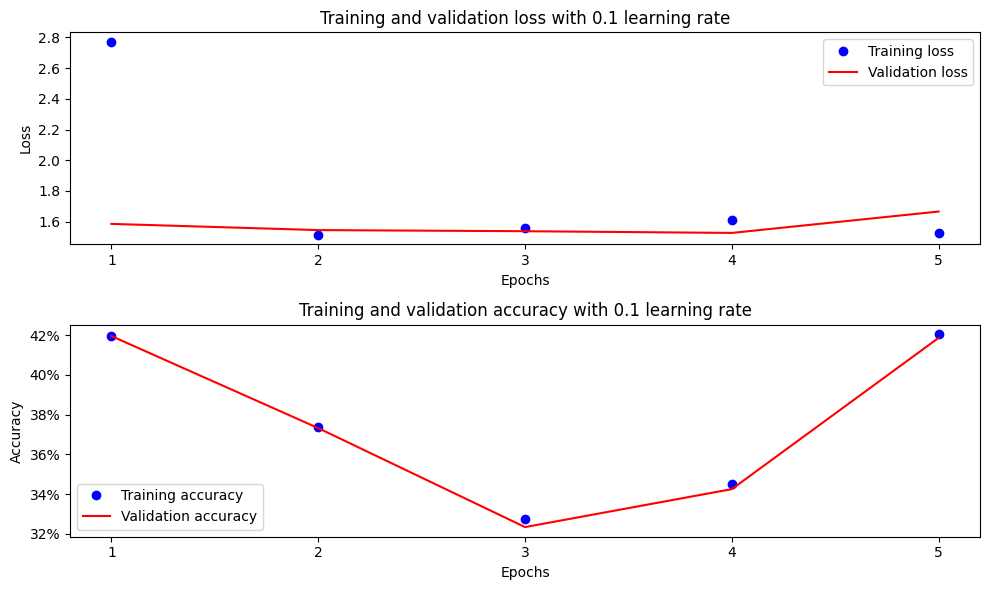

In [ ]:
train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    lr=1e-1,
    epochs_count=5
)

plot_result(
    train_losses,
    train_accuracies,
    val_losses,
    val_accuracies,
    lr=0.1
)

Epoch: 1
Train Loss: 0.47294159911473593
Train Accuracy: 0.8664666666666667
Validation Loss: 0.4112977087497711
Validation Accuracy: 0.8531
----------------------------------------
Epoch: 2
Train Loss: 0.3583625814358393
Train Accuracy: 0.8715666666666667
Validation Loss: 0.39763444662094116
Validation Accuracy: 0.8547
----------------------------------------
Epoch: 3
Train Loss: 0.3199176838775476
Train Accuracy: 0.8960833333333333
Validation Loss: 0.3496011793613434
Validation Accuracy: 0.8744
----------------------------------------
Epoch: 4
Train Loss: 0.296635307041804
Train Accuracy: 0.9012
Validation Loss: 0.3413086235523224
Validation Accuracy: 0.8748
----------------------------------------
Epoch: 5
Train Loss: 0.27541605543593567
Train Accuracy: 0.9052833333333333
Validation Loss: 0.3386852443218231
Validation Accuracy: 0.8815
----------------------------------------


/tmp/ipykernel_7937/1376204521.py:186: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])


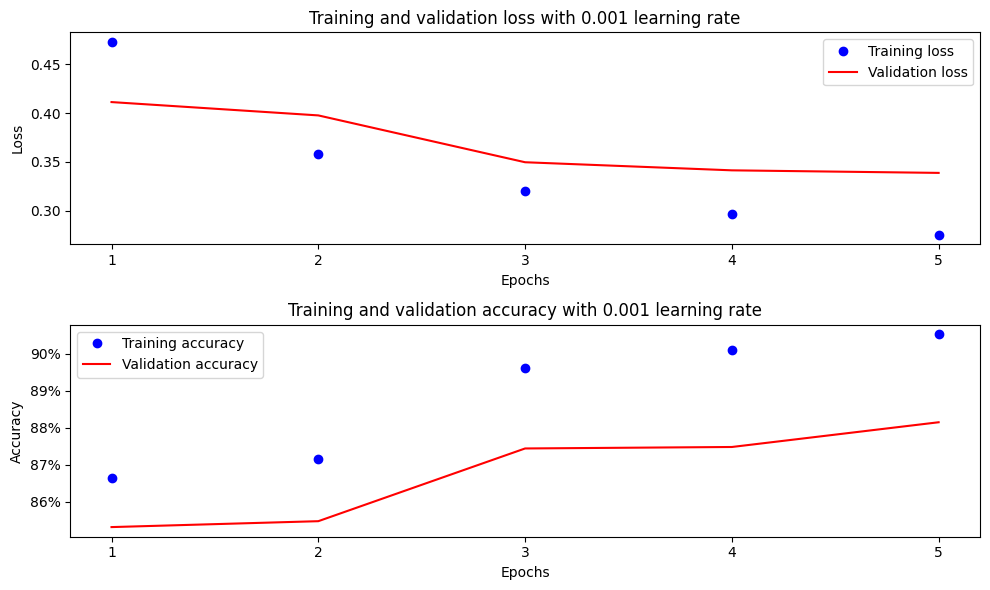

In [ ]:
train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    lr=1e-3,
    epochs_count=5
)

plot_result(
    train_losses,
    train_accuracies,
    val_losses,
    val_accuracies,
    lr=0.001
)

Epoch: 1
Train Loss: 1.1738694272359211
Train Accuracy: 0.75165
Validation Loss: 0.7892950773239136
Validation Accuracy: 0.739
----------------------------------------
Epoch: 2
Train Loss: 0.6889761009057362
Train Accuracy: 0.7958166666666666
Validation Loss: 0.6473416090011597
Validation Accuracy: 0.7833
----------------------------------------
Epoch: 3
Train Loss: 0.5924665277640024
Train Accuracy: 0.8168166666666666
Validation Loss: 0.5850958228111267
Validation Accuracy: 0.804
----------------------------------------
Epoch: 4
Train Loss: 0.5429510297934215
Train Accuracy: 0.8264166666666667
Validation Loss: 0.5518355965614319
Validation Accuracy: 0.8132
----------------------------------------
Epoch: 5
Train Loss: 0.511780038022995
Train Accuracy: 0.8313166666666667
Validation Loss: 0.5262928605079651
Validation Accuracy: 0.8199
----------------------------------------


/tmp/ipykernel_7937/1376204521.py:186: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])


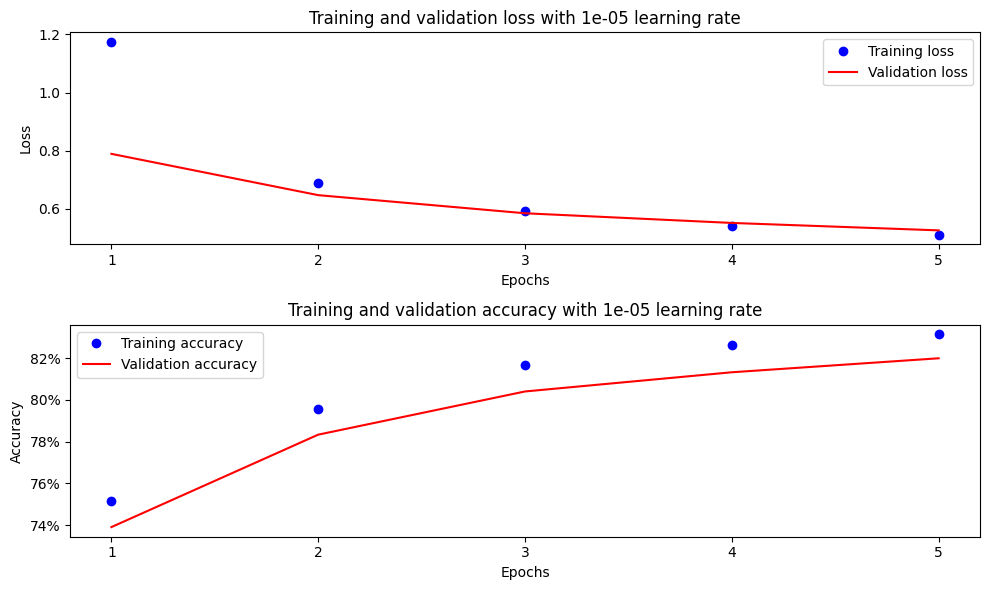

In [ ]:
train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    lr=1e-5,
    epochs_count=5
)

plot_result(
    train_losses,
    train_accuracies,
    val_losses,
    val_accuracies,
    lr=0.00001
)

0
1
2
3
4


/tmp/ipykernel_7937/170948817.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])


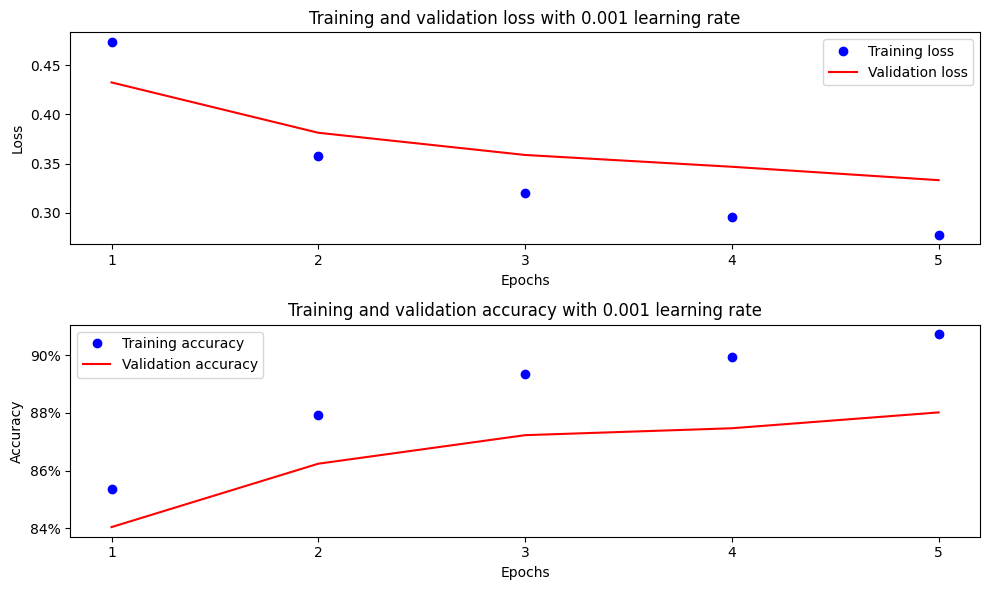

In [ ]:
# ================================
# TỐC ĐỘ HỌC TRUNG BÌNH: lr = 0.001
# ================================

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(5) + 1

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

0
1
2
3
4


/tmp/ipykernel_7937/3650037045.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])


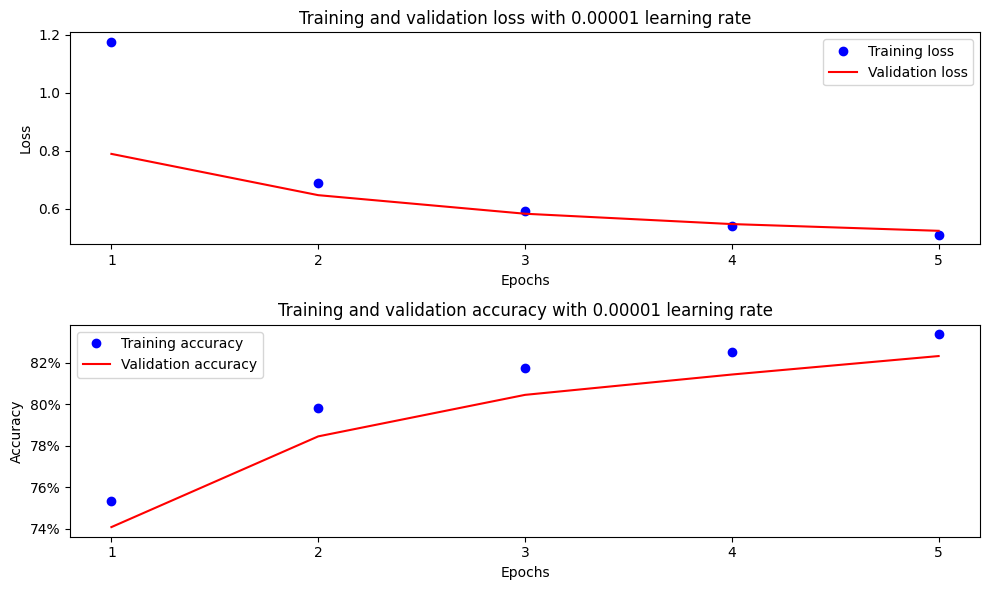

In [ ]:
# ================================
# TỐC ĐỘ HỌC THẤP: lr = 0.00001
# ================================

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-5)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(5) + 1

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# So sánh learning rate = 0.1, 0.001, 0.00001
# Dữ liệu đã chia /255
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam


def get_model_by_lr(lr):
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)

    return model, loss_fn, optimizer


def train_and_get_model(lr, epochs_count=5):
    trn_dl, val_dl = get_data()
    model, loss_fn, optimizer = get_model_by_lr(lr)

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(epochs_count):
        print("Learning rate:", lr, "- Epoch:", epoch)

        train_epoch_losses, train_epoch_accuracies = [], []

        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            batch_loss = train_batch(x, y, model, optimizer, loss_fn)
            train_epoch_losses.append(batch_loss)

        train_epoch_loss = np.array(train_epoch_losses).mean()

        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            is_correct = accuracy(x, y, model)
            train_epoch_accuracies.extend(is_correct)

        train_epoch_accuracy = np.mean(train_epoch_accuracies)

        for ix, batch in enumerate(iter(val_dl)):
            x, y = batch
            val_is_correct = accuracy(x, y, model)
            validation_loss = val_loss(x, y, model, loss_fn)

        val_epoch_accuracy = np.mean(val_is_correct)

        train_losses.append(train_epoch_loss)
        train_accuracies.append(train_epoch_accuracy)
        val_losses.append(validation_loss)
        val_accuracies.append(val_epoch_accuracy)

    return model


# Train lại 3 model để lấy trọng số
model_lr_01 = train_and_get_model(lr=1e-1, epochs_count=5)
model_lr_0001 = train_and_get_model(lr=1e-3, epochs_count=5)
model_lr_000001 = train_and_get_model(lr=1e-5, epochs_count=5)

Learning rate: 0.1 - Epoch: 0
Learning rate: 0.1 - Epoch: 1
Learning rate: 0.1 - Epoch: 2
Learning rate: 0.1 - Epoch: 3
Learning rate: 0.1 - Epoch: 4
Learning rate: 0.001 - Epoch: 0
Learning rate: 0.001 - Epoch: 1
Learning rate: 0.001 - Epoch: 2
Learning rate: 0.001 - Epoch: 3
Learning rate: 0.001 - Epoch: 4
Learning rate: 1e-05 - Epoch: 0
Learning rate: 1e-05 - Epoch: 1
Learning rate: 1e-05 - Epoch: 2
Learning rate: 1e-05 - Epoch: 3
Learning rate: 1e-05 - Epoch: 4


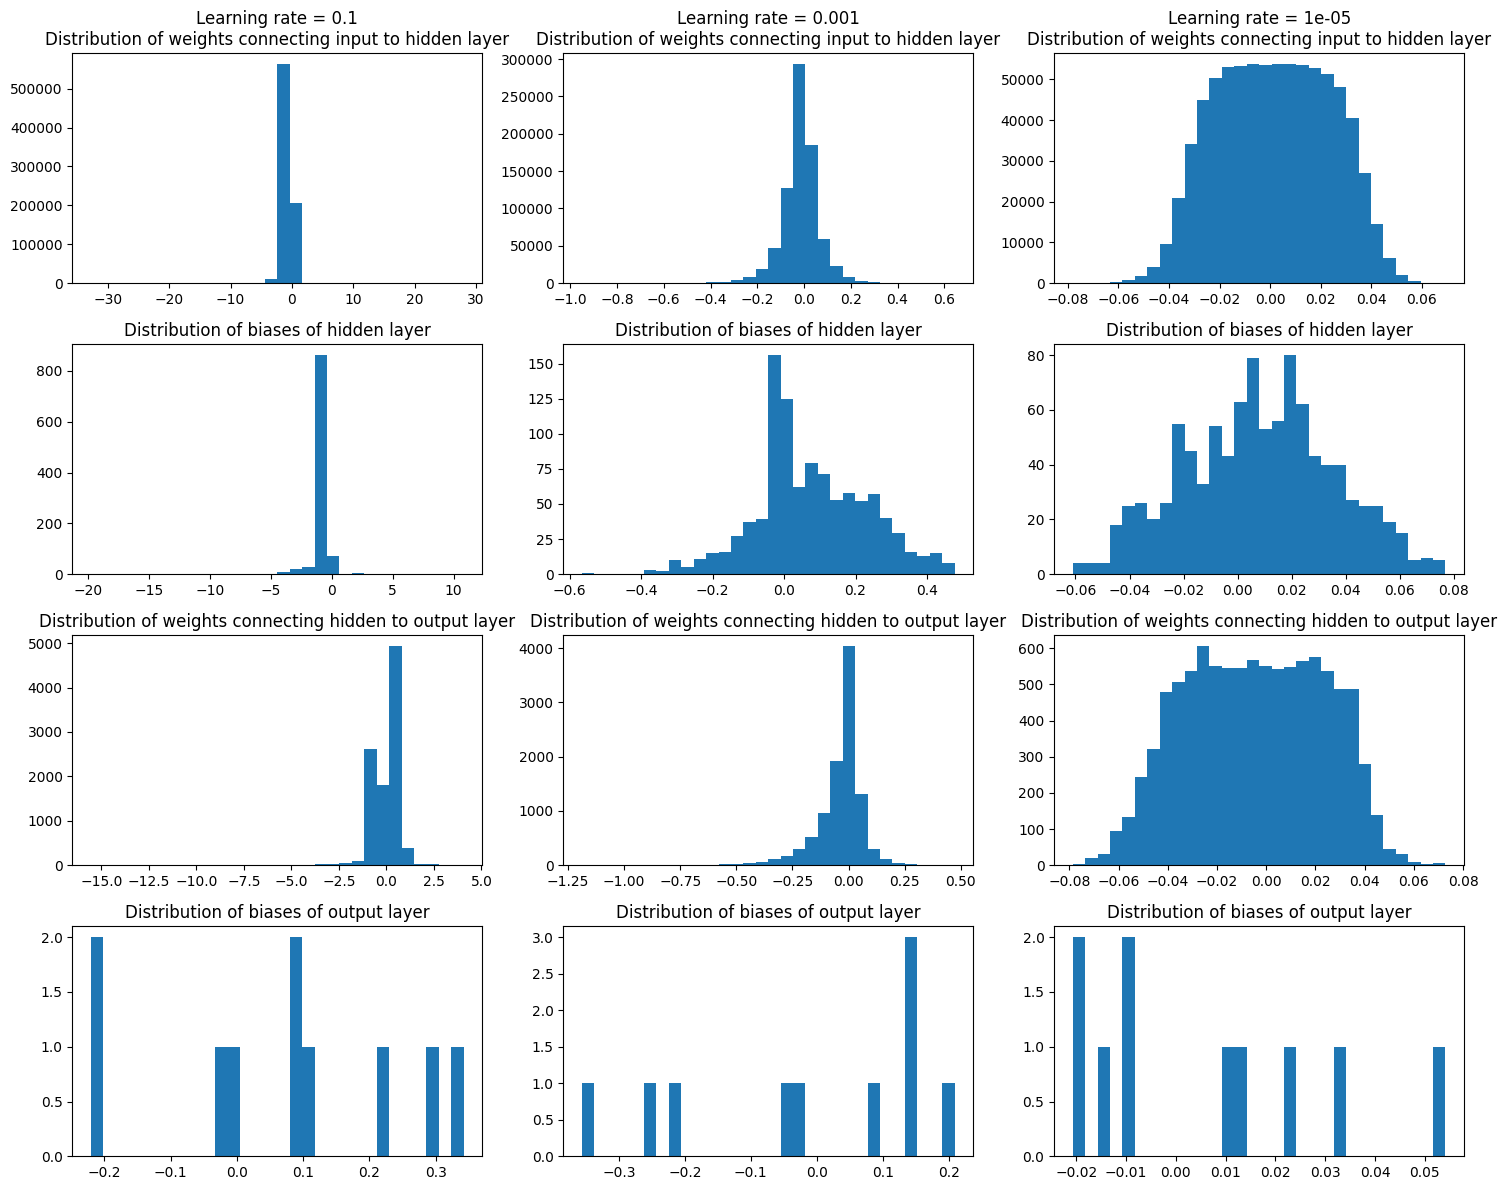

In [ ]:
# ============================================================
# VẼ HISTOGRAM PHÂN PHỐI TRỌNG SỐ
# ============================================================

models = [model_lr_01, model_lr_0001, model_lr_000001]
learning_rates = [0.1, 0.001, 0.00001]

plt.figure(figsize=(15, 12))

for col, model in enumerate(models):
    lr = learning_rates[col]

    # Trọng số và bias của lớp input -> hidden
    w1 = model[0].weight.detach().cpu().numpy().flatten()
    b1 = model[0].bias.detach().cpu().numpy().flatten()

    # Trọng số và bias của lớp hidden -> output
    w2 = model[2].weight.detach().cpu().numpy().flatten()
    b2 = model[2].bias.detach().cpu().numpy().flatten()

    plt.subplot(4, 3, col + 1)
    plt.hist(w1, bins=30)
    plt.title(f"Learning rate = {lr}\nDistribution of weights connecting input to hidden layer")

    plt.subplot(4, 3, col + 4)
    plt.hist(b1, bins=30)
    plt.title("Distribution of biases of hidden layer")

    plt.subplot(4, 3, col + 7)
    plt.hist(w2, bins=30)
    plt.title("Distribution of weights connecting hidden to output layer")

    plt.subplot(4, 3, col + 10)
    plt.hist(b2, bins=30)
    plt.title("Distribution of biases of output layer")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TÁC ĐỘNG CỦA TỐC ĐỘ HỌC TRÊN DỮ LIỆU KHÔNG CHIA /255
# ============================================================

from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets


# Dataset KHÔNG chia cho 255
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


def get_model(lr):
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)

    return model, loss_fn, optimizer


def train_batch(x, y, model, optimizer, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    return batch_loss.item()


@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()

    prediction = model(x)
    validation_loss = loss_fn(prediction, y)

    return validation_loss.item()


def run_lr_experiment(lr, epochs_count=5):
    trn_dl, val_dl = get_data()
    model, loss_fn, optimizer = get_model(lr)

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(epochs_count):
        print("Learning rate:", lr, "- Epoch:", epoch)

        train_epoch_losses, train_epoch_accuracies = [], []

        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            batch_loss = train_batch(x, y, model, optimizer, loss_fn)
            train_epoch_losses.append(batch_loss)

        train_epoch_loss = np.array(train_epoch_losses).mean()

        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            is_correct = accuracy(x, y, model)
            train_epoch_accuracies.extend(is_correct)

        train_epoch_accuracy = np.mean(train_epoch_accuracies)

        for ix, batch in enumerate(iter(val_dl)):
            x, y = batch
            val_is_correct = accuracy(x, y, model)
            validation_loss = val_loss(x, y, model, loss_fn)

        val_epoch_accuracy = np.mean(val_is_correct)

        train_losses.append(train_epoch_loss)
        train_accuracies.append(train_epoch_accuracy)
        val_losses.append(validation_loss)
        val_accuracies.append(val_epoch_accuracy)

    return model, train_losses, train_accuracies, val_losses, val_accuracies

Device: cpu


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.64MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 140kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.64MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.0MB/s]


Learning rate: 0.1 - Epoch: 0
Learning rate: 0.1 - Epoch: 1
Learning rate: 0.1 - Epoch: 2
Learning rate: 0.1 - Epoch: 3
Learning rate: 0.1 - Epoch: 4


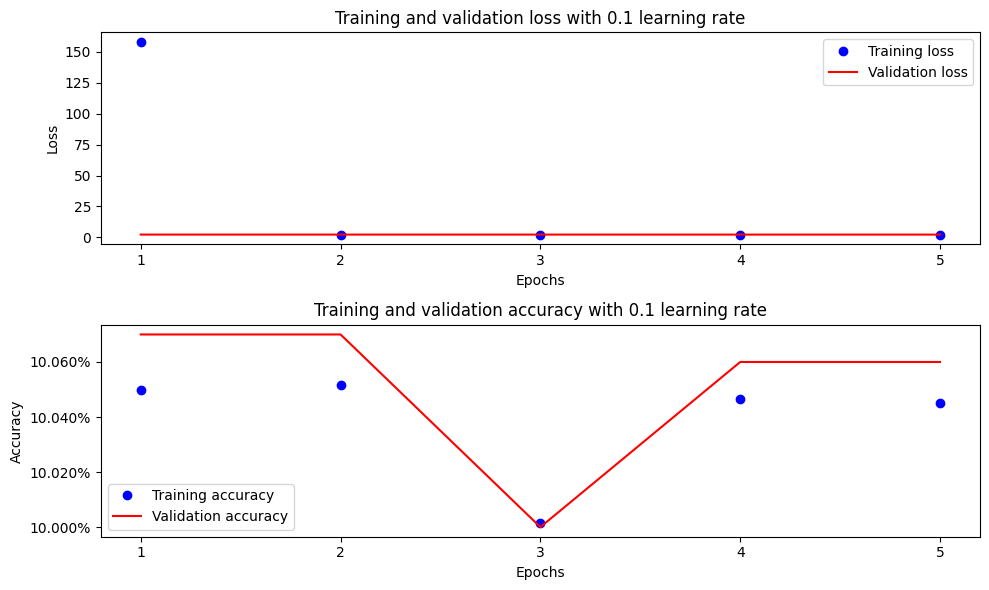

In [ ]:
# ============================================================
# KHÔNG CHIA /255 - LEARNING RATE = 0.1
# ============================================================

model_no_scale_01, train_losses, train_accuracies, val_losses, val_accuracies = run_lr_experiment(
    lr=1e-1,
    epochs_count=5
)

epochs = np.arange(5) + 1

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, "bo", label="Training loss")
plt.plot(epochs, val_losses, "r", label="Validation loss")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation loss with 0.1 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation accuracy with 0.1 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

Learning rate: 0.001 - Epoch: 0
Learning rate: 0.001 - Epoch: 1
Learning rate: 0.001 - Epoch: 2
Learning rate: 0.001 - Epoch: 3
Learning rate: 0.001 - Epoch: 4


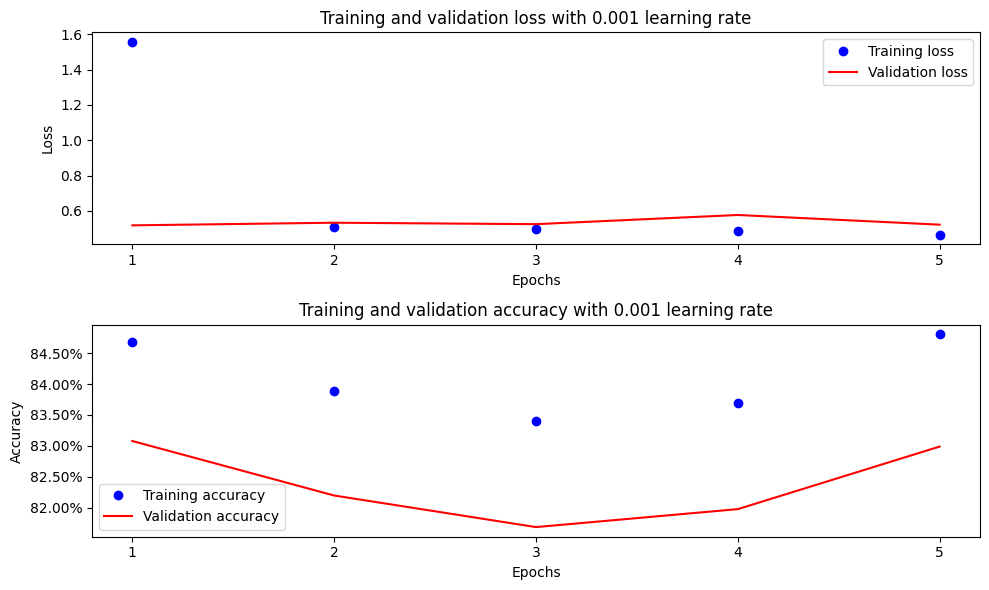

In [ ]:
# ============================================================
# KHÔNG CHIA /255 - LEARNING RATE = 0.001
# ============================================================

model_no_scale_0001, train_losses, train_accuracies, val_losses, val_accuracies = run_lr_experiment(
    lr=1e-3,
    epochs_count=5
)

epochs = np.arange(5) + 1

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, "bo", label="Training loss")
plt.plot(epochs, val_losses, "r", label="Validation loss")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation loss with 0.001 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation accuracy with 0.001 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

Learning rate: 1e-05 - Epoch: 0
Learning rate: 1e-05 - Epoch: 1
Learning rate: 1e-05 - Epoch: 2
Learning rate: 1e-05 - Epoch: 3
Learning rate: 1e-05 - Epoch: 4


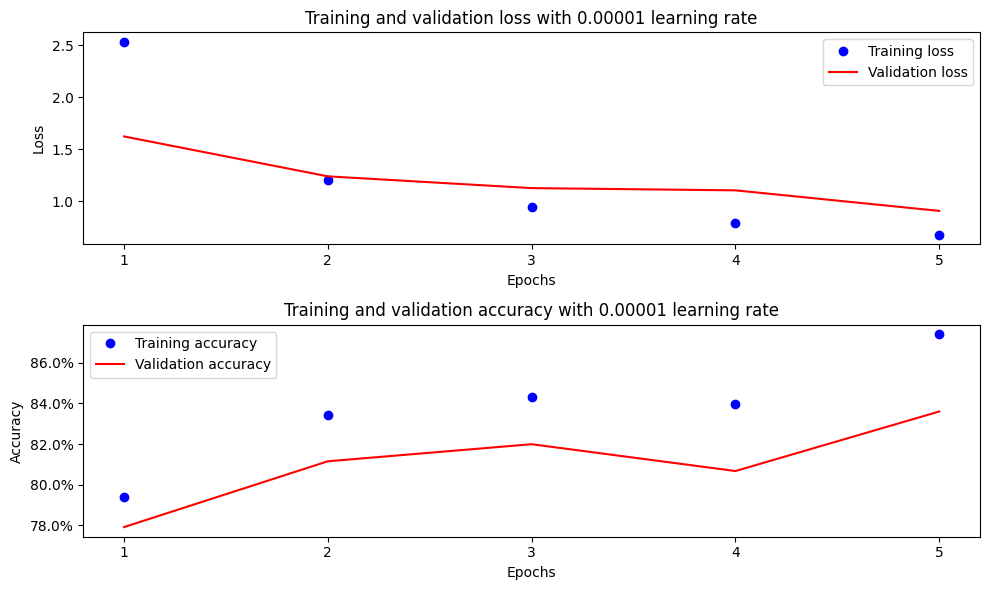

In [ ]:
# ============================================================
# KHÔNG CHIA /255 - LEARNING RATE = 0.00001
# ============================================================

model_no_scale_000001, train_losses, train_accuracies, val_losses, val_accuracies = run_lr_experiment(
    lr=1e-5,
    epochs_count=5
)

epochs = np.arange(5) + 1

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, "bo", label="Training loss")
plt.plot(epochs, val_losses, "r", label="Validation loss")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation loss with 0.00001 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation accuracy with 0.00001 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

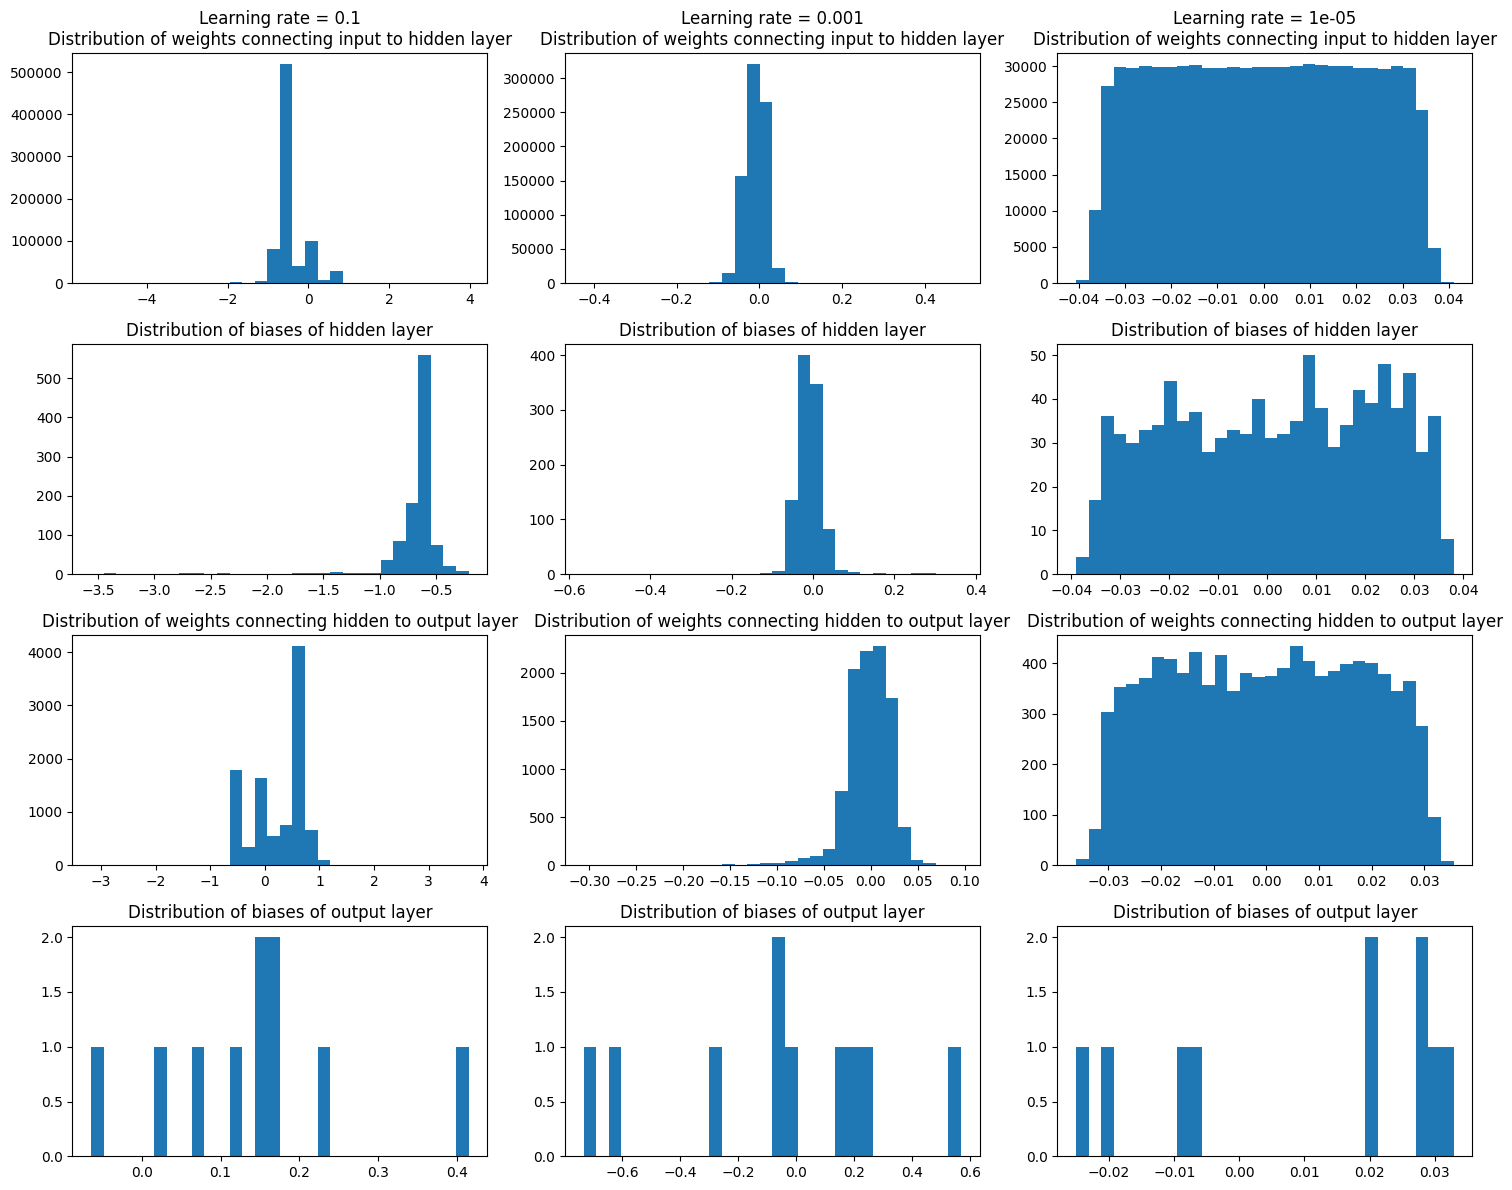

In [ ]:
# ============================================================
# PHÂN PHỐI TRỌNG SỐ - DỮ LIỆU KHÔNG CHIA /255
# ============================================================

models = [
    model_no_scale_01,
    model_no_scale_0001,
    model_no_scale_000001
]

learning_rates = [
    0.1,
    0.001,
    0.00001
]

plt.figure(figsize=(15, 12))

for col, model in enumerate(models):
    lr = learning_rates[col]

    w1 = model[0].weight.detach().cpu().numpy().flatten()
    b1 = model[0].bias.detach().cpu().numpy().flatten()
    w2 = model[2].weight.detach().cpu().numpy().flatten()
    b2 = model[2].bias.detach().cpu().numpy().flatten()

    plt.subplot(4, 3, col + 1)
    plt.hist(w1, bins=30)
    plt.title(f"Learning rate = {lr}\nDistribution of weights connecting input to hidden layer")

    plt.subplot(4, 3, col + 4)
    plt.hist(b1, bins=30)
    plt.title("Distribution of biases of hidden layer")

    plt.subplot(4, 3, col + 7)
    plt.hist(w2, bins=30)
    plt.title("Distribution of weights connecting hidden to output layer")

    plt.subplot(4, 3, col + 10)
    plt.hist(b2, bins=30)
    plt.title("Distribution of biases of output layer")

plt.tight_layout()
plt.show()